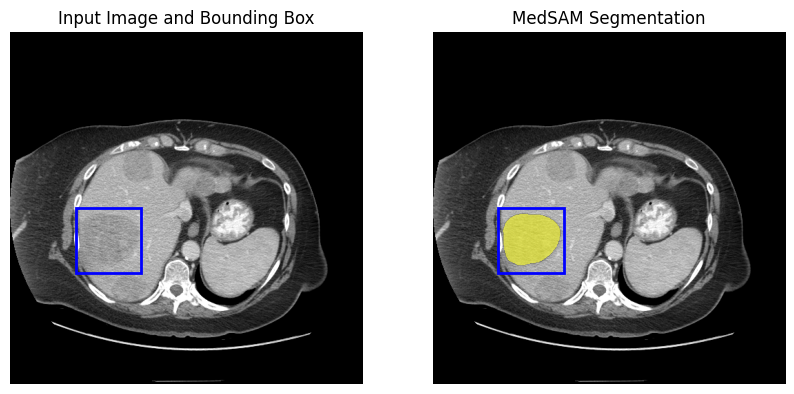

In [7]:
import requests

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from transformers import SamModel, SamProcessor
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

model = SamModel.from_pretrained("flaviagiammarino/medsam-vit-base").to(device)
processor = SamProcessor.from_pretrained("flaviagiammarino/medsam-vit-base")

img_url = "https://huggingface.co/flaviagiammarino/medsam-vit-base/resolve/main/scripts/input.png"
raw_image = Image.open(requests.get(img_url, stream=True).raw).convert("RGB")
input_boxes = [95., 255., 190., 350.]

inputs = processor(raw_image, input_boxes=[[input_boxes]], return_tensors="pt").to(device)
outputs = model(**inputs, multimask_output=False)
probs = processor.image_processor.post_process_masks(outputs.pred_masks.sigmoid().cpu(), inputs["original_sizes"].cpu(), inputs["reshaped_input_sizes"].cpu(), binarize=False)

def show_mask(mask, ax, random_color):
    if random_color:
        color = np.concatenate([np.random.random(3), np.array([0.6])], axis=0)
    else:
        color = np.array([251/255, 252/255, 30/255, 0.6])
    h, w = mask.shape[-2:]
    mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    ax.imshow(mask_image)

def show_box(box, ax):
    x0, y0 = box[0], box[1]
    w, h = box[2] - box[0], box[3] - box[1]
    ax.add_patch(plt.Rectangle((x0, y0), w, h, edgecolor="blue", facecolor=(0, 0, 0, 0), lw=2))

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(np.array(raw_image))
show_box(input_boxes, ax[0])
ax[0].set_title("Input Image and Bounding Box")
ax[0].axis("off")
ax[1].imshow(np.array(raw_image))
show_mask(mask=probs[0] > 0.5, ax=ax[1], random_color=False)
show_box(input_boxes, ax[1])
ax[1].set_title("MedSAM Segmentation")
ax[1].axis("off")
plt.show()


In [6]:
(probs[0] > 0.5).sum()

tensor(0)

In [18]:
outputs.keys()

odict_keys(['iou_scores', 'pred_masks'])

In [ ]:
processor.image_processor.post_process_for_mask_generation(
    
)